In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Equity Factor Research: Momentum and Volatility Factors

## Project Overview

In this project, I analyze whether simple momentum and volatility-based factors can explain future stock returns.

The goal is not to build a complete trading strategy, but to understand whether certain stock characteristics are related to future performance.

This type of analysis is commonly used in quantitative finance to test whether a signal has predictive power before turning it into a portfolio or trading strategy.

## Research Question

The main question of this project is:

> Can past momentum and volatility help explain future 20-day stock returns?

More specifically, this project investigates the following questions:

1. Do stocks with higher recent momentum generate higher future returns?
2. Do stocks with higher recent volatility generate higher future returns?
3. Which factor performs better: momentum or volatility?
4. Are the results robust after removing highly influential stocks such as NVDA and TSLA?

## Dataset

The analysis uses historical adjusted close price data for 15 large-cap US stocks between 2015 and 2025.

The selected stock universe includes:

- AAPL
- MSFT
- AMZN
- GOOGL
- META
- NVDA
- TSLA
- JPM
- JNJ
- PG
- XOM
- KO
- PEP
- WMT
- UNH

Adjusted close prices are used because they account for stock splits and dividends.

## Factors Tested

Four simple factors are tested in this project:

| Factor | Description |
|---|---|
| momentum_20d | 20-day price momentum |
| momentum_60d | 60-day price momentum |
| volatility_20d | 20-day rolling volatility |
| volatility_60d | 60-day rolling volatility |

## Target Variable

The target variable is:

| Target | Description |
|---|---|
| future_return_20d | Stock return over the next 20 trading days |

The factor values are calculated using past data, while the target variable is calculated using future returns.

This structure allows us to test whether today’s factor values are related to future stock performance.

## Methodology

The project follows these steps:

1. Download historical price data
2. Calculate daily returns
3. Create momentum and volatility factors
4. Calculate future 20-day returns
5. Perform quantile analysis
6. Calculate Information Coefficient values
7. Compare factor performance
8. Run a robustness check by excluding NVDA and TSLA
9. Interpret the results

## Important Note

This project is a factor research study, not a complete trading strategy.

The results should not be interpreted as direct investment advice or as a ready-to-trade model. A real trading strategy would also need transaction costs, slippage, risk management, portfolio construction, and out-of-sample validation.

In [2]:
!pip install yfinance -q

In [3]:
import pandas as pd
import numpy as np
import yfinance as yf

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

In [4]:
tickers = [
    "AAPL", "MSFT", "AMZN", "GOOGL", "META",
    "NVDA", "TSLA", "JPM", "JNJ", "PG",
    "XOM", "KO", "PEP", "WMT", "UNH"
]

start_date = "2015-01-01"
end_date = "2025-12-31"

In [5]:
raw_data = yf.download(
    tickers=tickers,
    start=start_date,
    end=end_date,
    auto_adjust=False,
    progress=False
)

raw_data.head()

Price       Adj Close                                                                                                                                                             Close                                                                                                                                                               High                                                                                                                                                                Low                                                                                                                                                               Open                                                                                                                                                             Volume                                                                                                                                         
Ticker           AAPL     AMZN      GOOGL        JNJ        JPM         KO       META       MSFT      NVDA        PEP         PG       TSLA        UNH        WMT        XOM       AAPL     AMZN      GOOGL         JNJ        JPM         KO       META       MSFT     NVDA        PEP         PG       TSLA         UNH        WMT        XOM       AAPL     AMZN      GOOGL         JNJ        JPM         KO       META       MSFT     NVDA        PEP         PG       TSLA         UNH        WMT        XOM       AAPL     AMZN      GOOGL         JNJ        JPM         KO       META       MSFT     NVDA        PEP         PG       TSLA         UNH        WMT        XOM       AAPL     AMZN      GOOGL         JNJ        JPM         KO       META       MSFT     NVDA        PEP         PG       TSLA         UNH        WMT        XOM       AAPL      AMZN     GOOGL      JNJ       JPM        KO      META      MSFT       NVDA      PEP       PG      TSLA      UNH       WMT       XOM
Date                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        
2015-01-02  24.214895  15.4260  26.260460  76.548630  46.274315  29.580006  77.839157  39.767681  0.482985  67.283447  65.555771  14.620667  83.828743  23.171682  57.533417  27.332500  15.4260  26.477501  104.519997  62.490002  42.139999  78.449997  46.759998  0.50325  94.440002  90.440002  14.620667  100.779999  28.633333  92.830002  27.860001  15.7375  26.790001  105.550003  62.959999  42.400002  78.930000  47.419998  0.50700  95.339996  91.000000  14.883333  102.620003  28.906668  93.050003  26.837500  15.3480  26.393999  104.129997  62.070000  41.799999  77.699997  46.540001  0.49525  94.050003  89.919998  14.217333  100.010002  28.516666  91.809998  27.847500  15.6290  26.629999  105.050003  62.180000  42.259998  78.580002  46.660000  0.50325  94.930000  90.839996  14.858000  101.500000  28.756666  92.250000  212818400  55664000  26480000  5753600  12600000   9921100  18177500  27913900  113680000  3545700  7251400  71466000  3060900  13505400  10220400
2015-01-05  23.532722  15.1095  25.760092  76.013992  44.837723  29.580006  76.588966  39.401993  0.474828  

In [6]:
prices = raw_data["Adj Close"]

prices.head()

Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,KO,META,MSFT,NVDA,PEP,PG,TSLA,UNH,WMT,XOM
Date,,,,,,,,,,,,,,,
2015-01-02,24.214895,15.4260,26.260460,76.548630,46.274315,29.580006,77.839157,39.767681,0.482985,67.283447,65.555771,14.620667,83.828743,23.171682,57.533417
2015-01-05,23.532722,15.1095,25.760092,76.013992,44.837723,29.580006,76.588966,39.401993,0.474828,66.777649,65.244064,14.006000,82.447975,23.104237,55.959213
2015-01-06,23.534935,14.7645,25.124348,75.640450,43.675133,29.804638,75.557076,38.823669,0.460432,66.271782,64.946884,14.085333,82.281631,23.282276,55.661728
2015-01-07,23.864943,14.9210,25.050457,77.310310,43.741783,30.176674,75.557076,39.316936,0.459232,68.209625,65.287567,14.063333,83.121727,23.900015,56.225700
2015-01-08,24.781893,15.0230,25.137737,77.918190,44.719246,30.541677,77.571259,40.473560,0.476507,69.449287,66.034172,14.041333,87.089424,24.404446,57.161556


In [7]:
print("Satır sayısı:", prices.shape[0])
print("Hisse sayısı:", prices.shape[1])

prices.tail()

Satır sayısı: 2765
Hisse sayısı: 15


Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,KO,META,MSFT,NVDA,PEP,PG,TSLA,UNH,WMT,XOM
Date,,,,,,,,,,,,,,,
2025-12-23,272.105377,232.139999,314.128876,204.691833,322.814331,69.392860,664.371155,485.741333,189.199768,142.407715,141.108017,485.559998,322.294373,110.672867,118.629288
2025-12-24,273.554016,232.380005,313.869049,206.681259,326.023376,69.631218,666.978943,486.908630,188.599792,142.467194,142.399094,485.399994,325.052917,111.381416,118.430618
2025-12-26,273.144409,232.520004,313.289459,206.532059,324.775421,69.392860,662.722595,486.599365,190.519684,142.506836,142.645462,475.190002,329.270142,111.511147,118.321342
2025-12-29,273.504089,232.070007,313.339417,206.462418,320.655182,69.680878,658.126526,485.990753,188.209808,142.962769,142.477921,459.640015,326.402435,112.299530,119.731941
2025-12-30,272.824707,232.529999,313.629242,205.815857,320.328339,69.591492,665.380310,486.369904,187.529846,142.883469,141.965439,454.429993,329.597626,111.690781,120.188896


In [8]:
missing_values = prices.isna().sum().sort_values(ascending=False)

missing_values

Ticker
AAPL     0
AMZN     0
GOOGL    0
JNJ      0
JPM      0
KO       0
META     0
MSFT     0
NVDA     0
PEP      0
PG       0
TSLA     0
UNH      0
WMT      0
XOM      0
dtype: int64

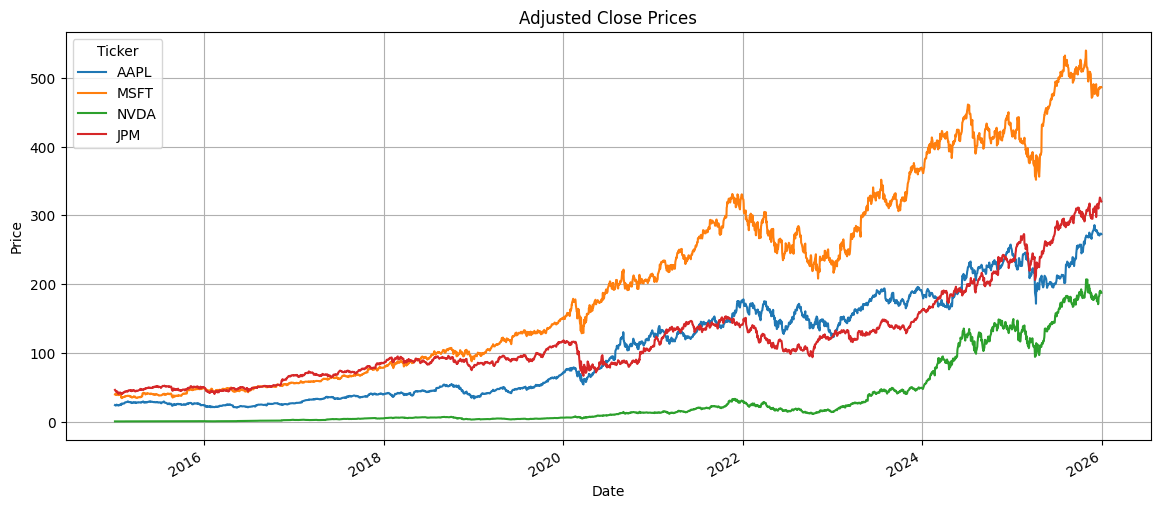

In [9]:
prices[["AAPL", "MSFT", "NVDA", "JPM"]].plot(figsize=(14, 6))

plt.title("Adjusted Close Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()

In [10]:
daily_returns = prices.pct_change()

daily_returns.head()

Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,KO,META,MSFT,NVDA,PEP,PG,TSLA,UNH,WMT,XOM
Date,,,,,,,,,,,,,,,
2015-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-05,-0.028172,-0.020517,-0.019054,-0.006984,-0.031045,0.000000,-0.016061,-0.009196,-0.016890,-0.007517,-0.004755,-0.042041,-0.016471,-0.002911,-0.027362
2015-01-06,0.000094,-0.022833,-0.024679,-0.004914,-0.025929,0.007594,-0.013473,-0.014678,-0.030319,-0.007575,-0.004555,0.005664,-0.002018,0.007706,-0.005316
2015-01-07,0.014022,0.010600,-0.002941,0.022076,0.001526,0.012482,0.000000,0.012705,-0.002605,0.029241,0.005246,-0.001562,0.010210,0.026533,0.010132
2015-01-08,0.038422,0.006836,0.003484,0.007863,0.022346,0.012096,0.026658,0.029418,0.037618,0.018174,0.011436,-0.001564,0.047734,0.021106,0.016645


In [11]:
daily_returns = daily_returns.dropna()

daily_returns.head()

Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,KO,META,MSFT,NVDA,PEP,PG,TSLA,UNH,WMT,XOM
Date,,,,,,,,,,,,,,,
2015-01-05,-0.028172,-0.020517,-0.019054,-0.006984,-0.031045,0.000000,-0.016061,-0.009196,-0.016890,-0.007517,-0.004755,-0.042041,-0.016471,-0.002911,-0.027362
2015-01-06,0.000094,-0.022833,-0.024679,-0.004914,-0.025929,0.007594,-0.013473,-0.014678,-0.030319,-0.007575,-0.004555,0.005664,-0.002018,0.007706,-0.005316
2015-01-07,0.014022,0.010600,-0.002941,0.022076,0.001526,0.012482,0.000000,0.012705,-0.002605,0.029241,0.005246,-0.001562,0.010210,0.026533,0.010132
2015-01-08,0.038422,0.006836,0.003484,0.007863,0.022346,0.012096,0.026658,0.029418,0.037618,0.018174,0.011436,-0.001564,0.047734,0.021106,0.016645
2015-01-09,0.001072,-0.011749,-0.012211,-0.013629,-0.017387,-0.011032,-0.005628,-0.008405,0.004028,-0.006770,-0.009331,-0.018802,-0.009360,-0.012380,-0.001410


In [12]:
print("Fiyat verisi boyutu:", prices.shape)
print("Getiri verisi boyutu:", daily_returns.shape)

Fiyat verisi boyutu: (2765, 15)
Getiri verisi boyutu: (2764, 15)


In [13]:
daily_returns.describe()

Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,KO,META,MSFT,NVDA,PEP,PG,TSLA,UNH,WMT,XOM
count,2764.000000,2764.000000,2764.000000,2764.000000,2764.000000,2764.000000,2764.000000,2764.000000,2764.000000,2764.000000,2764.000000,2764.000000,2764.000000,2764.000000,2764.000000
mean,0.001041,0.001196,0.001062,0.000424,0.000846,0.000372,0.001059,0.001050,0.002625,0.000345,0.000348,0.001903,0.000662,0.000661,0.000416
std,0.018174,0.020746,0.018172,0.011467,0.017105,0.011189,0.023646,0.016940,0.030678,0.011991,0.011664,0.036386,0.018103,0.013553,0.017274
min,-0.128647,-0.140494,-0.116341,-0.100379,-0.149649,-0.096725,-0.263901,-0.147390,-0.187559,-0.114283,-0.087373,-0.210628,-0.223797,-0.113757,-0.122248
25%,-0.007289,-0.008797,-0.007685,-0.004875,-0.007015,-0.004711,-0.009449,-0.006721,-0.012410,-0.005184,-0.005122,-0.016541,-0.007163,-0.005625,-0.008183
50%,0.000951,0.001082,0.001294,0.000464,0.000693,0.000481,0.000989,0.000957,0.002655,0.000383,0.000582,0.001258,0.000795,0.000740,0.000269
75%,0.010015,0.011438,0.009979,0.005999,0.008938,0.005887,0.012153,0.009431,0.017724,0.006148,0.006288,0.019587,0.008585,0.007081,0.009027
max,0.153288,0.141311,0.162584,0.079977,0.180125,0.064796,0.232824,0.142169,0.298067,0.129366,0.120090,0.226900,0.127989,0.117085,0.126868


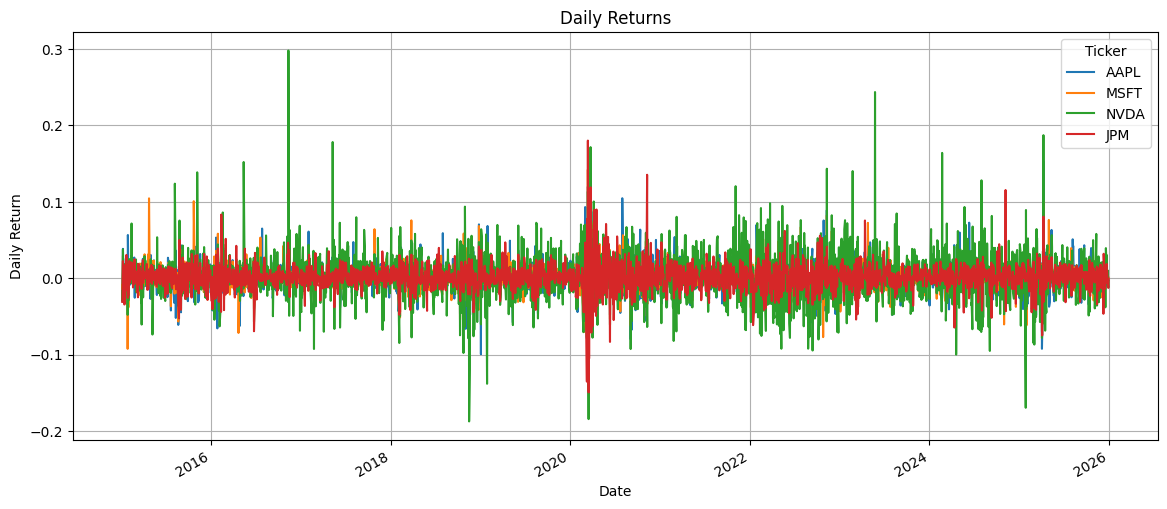

In [14]:
daily_returns[["AAPL", "MSFT", "NVDA", "JPM"]].plot(figsize=(14, 6))

plt.title("Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.grid(True)
plt.show()

In [15]:
momentum_20d = prices / prices.shift(20) - 1
momentum_60d = prices / prices.shift(60) - 1

momentum_20d.head(25)

Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,KO,META,MSFT,NVDA,PEP,PG,TSLA,UNH,WMT,XOM
Date,,,,,,,,,,,,,,,
2015-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
volatility_20d = daily_returns.rolling(window=20).std()
volatility_60d = daily_returns.rolling(window=60).std()

volatility_20d.head(25)

Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,KO,META,MSFT,NVDA,PEP,PG,TSLA,UNH,WMT,XOM
Date,,,,,,,,,,,,,,,
2015-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
factor_data = pd.DataFrame()

factor_data["price"] = prices.stack()
factor_data["daily_return"] = daily_returns.stack()
factor_data["momentum_20d"] = momentum_20d.stack()
factor_data["momentum_60d"] = momentum_60d.stack()
factor_data["volatility_20d"] = volatility_20d.stack()
factor_data["volatility_60d"] = volatility_60d.stack()

factor_data = factor_data.reset_index()

factor_data.columns = [
    "date",
    "ticker",
    "price",
    "daily_return",
    "momentum_20d",
    "momentum_60d",
    "volatility_20d",
    "volatility_60d"
]

factor_data.head()

,date,ticker,price,daily_return,momentum_20d,momentum_60d,volatility_20d,volatility_60d
0,2015-01-02,AAPL,24.214895,NaN,NaN,NaN,NaN,NaN
1,2015-01-02,AMZN,15.426000,NaN,NaN,NaN,NaN,NaN
2,2015-01-02,GOOGL,26.260460,NaN,NaN,NaN,NaN,NaN
3,2015-01-02,JNJ,76.548630,NaN,NaN,NaN,NaN,NaN
4,2015-01-02,JPM,46.274315,NaN,NaN,NaN,NaN,NaN


In [18]:
factor_data.shape

(41475, 8)

In [19]:
factor_data.head(10)

,date,ticker,price,daily_return,momentum_20d,momentum_60d,volatility_20d,volatility_60d
0,2015-01-02,AAPL,24.214895,NaN,NaN,NaN,NaN,NaN
1,2015-01-02,AMZN,15.426000,NaN,NaN,NaN,NaN,NaN
2,2015-01-02,GOOGL,26.260460,NaN,NaN,NaN,NaN,NaN
3,2015-01-02,JNJ,76.548630,NaN,NaN,NaN,NaN,NaN
4,2015-01-02,JPM,46.274315,NaN,NaN,NaN,NaN,NaN
5,2015-01-02,KO,29.580006,NaN,NaN,NaN,NaN,NaN
6,2015-01-02,META,77.839157,NaN,NaN,NaN,NaN,NaN
7,2015-01-02,MSFT,39.767681,NaN,NaN,NaN,NaN,NaN
8,2015-01-02,NVDA,0.482985,NaN,NaN,NaN,NaN,NaN
9,2015-01-02,PEP,67.283447,NaN,NaN,NaN,NaN,NaN


In [20]:
factor_data.isna().sum()

date                0
ticker              0
price               0
daily_return       15
momentum_20d      300
momentum_60d      900
volatility_20d    300
volatility_60d    900
dtype: int64

In [21]:
factor_data = factor_data.dropna()

factor_data.head()

,date,ticker,price,daily_return,momentum_20d,momentum_60d,volatility_20d,volatility_60d
900,2015-03-31,AAPL,27.668076,-0.015352,-0.038111,0.142606,0.014401,0.017536
901,2015-03-31,AMZN,18.605000,-0.006647,-0.032526,0.206081,0.011759,0.022583
902,2015-03-31,GOOGL,27.507648,-0.011477,-0.041621,0.047493,0.012188,0.014493
903,2015-03-31,JNJ,74.193459,-0.009354,-0.017002,-0.030767,0.011795,0.011548
904,2015-03-31,JPM,44.859947,-0.006234,-0.022430,-0.030565,0.012227,0.015263


In [22]:
print("Factor data boyutu:", factor_data.shape)

factor_data.head()

Factor data boyutu: (40575, 8)


,date,ticker,price,daily_return,momentum_20d,momentum_60d,volatility_20d,volatility_60d
900,2015-03-31,AAPL,27.668076,-0.015352,-0.038111,0.142606,0.014401,0.017536
901,2015-03-31,AMZN,18.605000,-0.006647,-0.032526,0.206081,0.011759,0.022583
902,2015-03-31,GOOGL,27.507648,-0.011477,-0.041621,0.047493,0.012188,0.014493
903,2015-03-31,JNJ,74.193459,-0.009354,-0.017002,-0.030767,0.011795,0.011548
904,2015-03-31,JPM,44.859947,-0.006234,-0.022430,-0.030565,0.012227,0.015263


In [23]:
factor_data.describe()

,date,price,daily_return,momentum_20d,momentum_60d,volatility_20d,volatility_60d
count,40575,40575.000000,40575.000000,40575.000000,40575.000000,40575.000000,40575.000000
mean,2020-08-12 07:47:24.066543616,126.382346,0.000946,0.018738,0.056918,0.016631,0.017211
min,2015-03-31 00:00:00,0.467248,-0.263901,-0.606265,-0.588690,0.002749,0.004120
25%,2017-12-04 00:00:00,48.503403,-0.007077,-0.024002,-0.026381,0.009500,0.010417
50%,2020-08-12 00:00:00,97.805946,0.000800,0.016088,0.043573,0.013429,0.014285
75%,2023-04-20 00:00:00,158.430824,0.009036,0.055822,0.118247,0.020132,0.020642
max,2025-12-30 00:00:00,788.148987,0.298067,1.063036,1.813269,0.100268,0.080515
std,NaN,114.728339,0.019816,0.087127,0.159896,0.010869,0.009840


In [24]:
factor_data.shape

(40575, 8)

In [25]:
factor_data.isna().sum()

date              0
ticker            0
price             0
daily_return      0
momentum_20d      0
momentum_60d      0
volatility_20d    0
volatility_60d    0
dtype: int64

In [26]:
future_return_20d = prices.shift(-20) / prices - 1

future_return_20d.head()

Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,KO,META,MSFT,NVDA,PEP,PG,TSLA,UNH,WMT,XOM
Date,,,,,,,,,,,,,,,
2015-01-02,0.085063,0.181350,0.005004,-0.035304,-0.112338,-0.013051,-0.044105,-0.117194,-0.025335,0.009424,-0.052130,-0.038165,0.064597,-0.002212,-0.035010
2015-01-05,0.116706,0.203051,0.026643,-0.012814,-0.063253,-0.012102,-0.023189,-0.102094,0.016169,0.026352,-0.038315,0.039364,0.087671,0.006305,0.021708
2015-01-06,0.125165,0.235226,0.038410,-0.018590,-0.044083,-0.018370,-0.006829,-0.083461,0.050547,0.038486,-0.035712,0.034409,0.090983,0.003939,0.018372
2015-01-07,0.117526,0.252899,0.048857,-0.029367,-0.038937,-0.027914,-0.007091,-0.081765,0.070533,0.009087,-0.030569,0.047594,0.088962,-0.014899,0.018078
2015-01-08,0.067114,0.245690,0.053205,-0.049723,-0.041398,-0.047345,-0.047455,-0.108846,0.027190,-0.007899,-0.053579,0.032001,0.027698,-0.034708,-0.000447


In [27]:
future_return_20d_long = future_return_20d.stack().reset_index()

future_return_20d_long.columns = ["date", "ticker", "future_return_20d"]

future_return_20d_long.head()

,date,ticker,future_return_20d
0,2015-01-02,AAPL,0.085063
1,2015-01-02,AMZN,0.181350
2,2015-01-02,GOOGL,0.005004
3,2015-01-02,JNJ,-0.035304
4,2015-01-02,JPM,-0.112338


In [28]:
factor_data = factor_data.merge(
    future_return_20d_long,
    on=["date", "ticker"],
    how="left"
)

factor_data.head()

,date,ticker,price,daily_return,momentum_20d,momentum_60d,volatility_20d,volatility_60d,future_return_20d
0,2015-03-31,AAPL,27.668076,-0.015352,-0.038111,0.142606,0.014401,0.017536,0.033834
1,2015-03-31,AMZN,18.605000,-0.006647,-0.032526,0.206081,0.011759,0.022583,0.153910
2,2015-03-31,GOOGL,27.507648,-0.011477,-0.041621,0.047493,0.012188,0.014493,0.012061
3,2015-03-31,JNJ,74.193459,-0.009354,-0.017002,-0.030767,0.011795,0.011548,-0.002088
4,2015-03-31,JPM,44.859947,-0.006234,-0.022430,-0.030565,0.012227,0.015263,0.056829


In [29]:
factor_data.isna().sum()

date                   0
ticker                 0
price                  0
daily_return           0
momentum_20d           0
momentum_60d           0
volatility_20d         0
volatility_60d         0
future_return_20d    300
dtype: int64

In [30]:
factor_data = factor_data.dropna().reset_index(drop=True)

print("Final factor data boyutu:", factor_data.shape)

factor_data.isna().sum()

Final factor data boyutu: (40275, 9)


date                 0
ticker               0
price                0
daily_return         0
momentum_20d         0
momentum_60d         0
volatility_20d       0
volatility_60d       0
future_return_20d    0
dtype: int64

In [31]:
factor_data.shape

(40275, 9)

In [32]:
factor_data.head()

,date,ticker,price,daily_return,momentum_20d,momentum_60d,volatility_20d,volatility_60d,future_return_20d
0,2015-03-31,AAPL,27.668076,-0.015352,-0.038111,0.142606,0.014401,0.017536,0.033834
1,2015-03-31,AMZN,18.605000,-0.006647,-0.032526,0.206081,0.011759,0.022583,0.153910
2,2015-03-31,GOOGL,27.507648,-0.011477,-0.041621,0.047493,0.012188,0.014493,0.012061
3,2015-03-31,JNJ,74.193459,-0.009354,-0.017002,-0.030767,0.011795,0.011548,-0.002088
4,2015-03-31,JPM,44.859947,-0.006234,-0.022430,-0.030565,0.012227,0.015263,0.056829


In [33]:
factor_data.isna().sum()

date                 0
ticker               0
price                0
daily_return         0
momentum_20d         0
momentum_60d         0
volatility_20d       0
volatility_60d       0
future_return_20d    0
dtype: int64

In [34]:
factor_data.groupby("date")["ticker"].nunique().describe()

count    2685.0
mean       15.0
std         0.0
min        15.0
25%        15.0
50%        15.0
75%        15.0
max        15.0
Name: ticker, dtype: float64

In [35]:
factor_data["momentum_20d_quantile"] = factor_data.groupby("date")["momentum_20d"].transform(
    lambda x: pd.qcut(x, q=5, labels=False, duplicates="drop") + 1
)

factor_data.head()

,date,ticker,price,daily_return,momentum_20d,momentum_60d,volatility_20d,volatility_60d,future_return_20d,momentum_20d_quantile
0,2015-03-31,AAPL,27.668076,-0.015352,-0.038111,0.142606,0.014401,0.017536,0.033834,2
1,2015-03-31,AMZN,18.605000,-0.006647,-0.032526,0.206081,0.011759,0.022583,0.153910,3
2,2015-03-31,GOOGL,27.507648,-0.011477,-0.041621,0.047493,0.012188,0.014493,0.012061,2
3,2015-03-31,JNJ,74.193459,-0.009354,-0.017002,-0.030767,0.011795,0.011548,-0.002088,4
4,2015-03-31,JPM,44.859947,-0.006234,-0.022430,-0.030565,0.012227,0.015263,0.056829,4


In [36]:
factor_data["momentum_20d_quantile"].value_counts().sort_index()

momentum_20d_quantile
1    8055
2    8055
3    8055
4    8055
5    8055
Name: count, dtype: int64

In [37]:
momentum_quantile_summary = factor_data.groupby("momentum_20d_quantile")["future_return_20d"].mean()

momentum_quantile_summary

momentum_20d_quantile
1    0.020229
2    0.016707
3    0.015114
4    0.016044
5    0.025967
Name: future_return_20d, dtype: float64

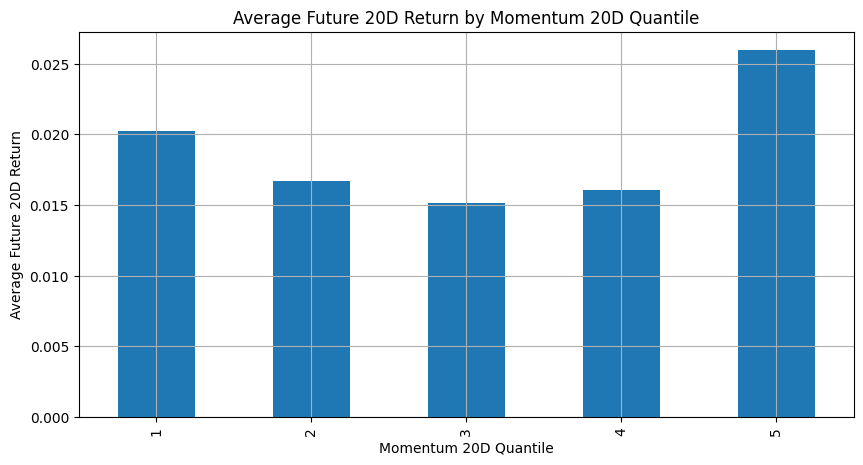

In [38]:
momentum_quantile_summary.plot(kind="bar", figsize=(10, 5))

plt.title("Average Future 20D Return by Momentum 20D Quantile")
plt.xlabel("Momentum 20D Quantile")
plt.ylabel("Average Future 20D Return")
plt.grid(True)
plt.show()

In [39]:
factor_data["momentum_20d_quantile"].value_counts().sort_index()

momentum_20d_quantile
1    8055
2    8055
3    8055
4    8055
5    8055
Name: count, dtype: int64

In [40]:
momentum_quantile_summary

momentum_20d_quantile
1    0.020229
2    0.016707
3    0.015114
4    0.016044
5    0.025967
Name: future_return_20d, dtype: float64

In [41]:
q5_return = momentum_quantile_summary.loc[5]
q1_return = momentum_quantile_summary.loc[1]

spread_q5_q1 = q5_return - q1_return

print("Q5 Return:", q5_return)
print("Q1 Return:", q1_return)
print("Q5 - Q1 Spread:", spread_q5_q1)

Q5 Return: 0.025966539326515648
Q1 Return: 0.020228614115164065
Q5 - Q1 Spread: 0.005737925211351583


In [42]:
def quantile_analysis(data, factor_col, target_col="future_return_20d", q=5):
    temp = data.copy()
    
    quantile_col = factor_col + "_quantile"
    
    temp[quantile_col] = temp.groupby("date")[factor_col].transform(
        lambda x: pd.qcut(x, q=q, labels=False, duplicates="drop") + 1
    )
    
    summary = temp.groupby(quantile_col)[target_col].mean()
    
    spread = summary.loc[q] - summary.loc[1]
    
    print(f"Factor: {factor_col}")
    print(summary)
    print()
    print(f"Q{q} - Q1 Spread:", spread)
    
    return summary, spread

In [43]:
momentum_60d_summary, momentum_60d_spread = quantile_analysis(
    factor_data,
    factor_col="momentum_60d"
)

Factor: momentum_60d
momentum_60d_quantile
1    0.021504
2    0.013968
3    0.013163
4    0.015322
5    0.030104
Name: future_return_20d, dtype: float64

Q5 - Q1 Spread: 0.008599998599012951


In [44]:
volatility_20d_summary, volatility_20d_spread = quantile_analysis(
    factor_data,
    factor_col="volatility_20d"
)

Factor: volatility_20d
volatility_20d_quantile
1    0.008082
2    0.010743
3    0.019648
4    0.020982
5    0.034606
Name: future_return_20d, dtype: float64

Q5 - Q1 Spread: 0.026524737977322067


In [45]:
volatility_60d_summary, volatility_60d_spread = quantile_analysis(
    factor_data,
    factor_col="volatility_60d"
)

Factor: volatility_60d
volatility_60d_quantile
1    0.007543
2    0.010531
3    0.018461
4    0.021022
5    0.036504
Name: future_return_20d, dtype: float64

Q5 - Q1 Spread: 0.0289606754089072


In [46]:
factor_comparison = pd.DataFrame({
    "factor": [
        "momentum_20d",
        "momentum_60d",
        "volatility_20d",
        "volatility_60d"
    ],
    "q1_return": [
        momentum_quantile_summary.loc[1],
        momentum_60d_summary.loc[1],
        volatility_20d_summary.loc[1],
        volatility_60d_summary.loc[1]
    ],
    "q5_return": [
        momentum_quantile_summary.loc[5],
        momentum_60d_summary.loc[5],
        volatility_20d_summary.loc[5],
        volatility_60d_summary.loc[5]
    ],
    "q5_q1_spread": [
        spread_q5_q1,
        momentum_60d_spread,
        volatility_20d_spread,
        volatility_60d_spread
    ]
})

factor_comparison

,factor,q1_return,q5_return,q5_q1_spread
0,momentum_20d,0.020229,0.025967,0.005738
1,momentum_60d,0.021504,0.030104,0.008600
2,volatility_20d,0.008082,0.034606,0.026525
3,volatility_60d,0.007543,0.036504,0.028961


In [47]:
factor_comparison.sort_values("q5_q1_spread", ascending=False)

,factor,q1_return,q5_return,q5_q1_spread
3,volatility_60d,0.007543,0.036504,0.028961
2,volatility_20d,0.008082,0.034606,0.026525
1,momentum_60d,0.021504,0.030104,0.008600
0,momentum_20d,0.020229,0.025967,0.005738


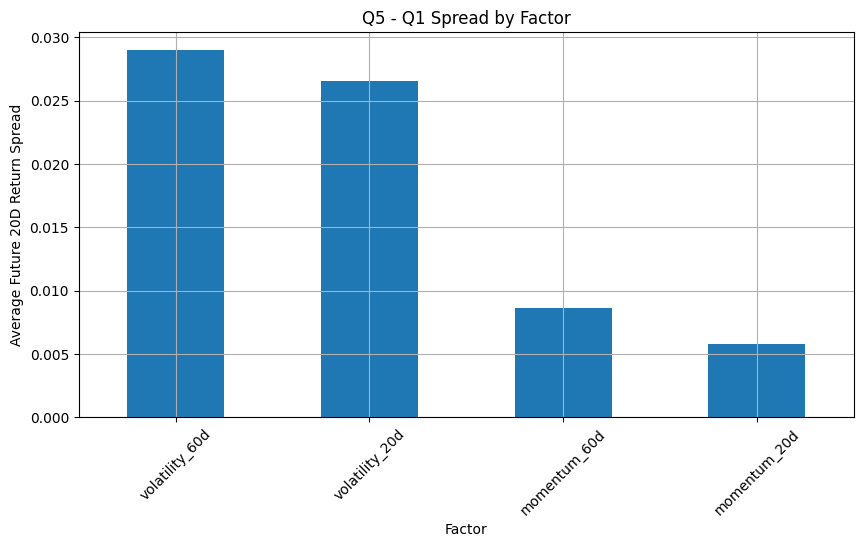

In [48]:
factor_comparison_sorted = factor_comparison.sort_values(
    "q5_q1_spread",
    ascending=False
)

factor_comparison_sorted.plot(
    x="factor",
    y="q5_q1_spread",
    kind="bar",
    figsize=(10, 5),
    legend=False
)

plt.title("Q5 - Q1 Spread by Factor")
plt.xlabel("Factor")
plt.ylabel("Average Future 20D Return Spread")
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

In [49]:
factor_comparison_percent = factor_comparison.copy()

for col in ["q1_return", "q5_return", "q5_q1_spread"]:
    factor_comparison_percent[col] = factor_comparison_percent[col] * 100

factor_comparison_percent = factor_comparison_percent.sort_values(
    "q5_q1_spread",
    ascending=False
)

factor_comparison_percent

,factor,q1_return,q5_return,q5_q1_spread
3,volatility_60d,0.754328,3.650395,2.896068
2,volatility_20d,0.808153,3.460627,2.652474
1,momentum_60d,2.150382,3.010382,0.860000
0,momentum_20d,2.022861,2.596654,0.573793


In [50]:
ic_momentum_20d = factor_data.groupby("date").apply(
    lambda x: x["momentum_20d"].corr(x["future_return_20d"])
)

ic_momentum_20d.head()

/tmp/ipykernel_16/4200725068.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ic_momentum_20d = factor_data.groupby("date").apply(


date
2015-03-31   -0.578755
2015-04-01   -0.695744
2015-04-02   -0.611664
2015-04-06   -0.109910
2015-04-07    0.092116
dtype: float64

In [51]:
ic_momentum_20d.describe()

count    2685.000000
mean        0.023504
std         0.396345
min        -0.916960
25%        -0.277733
50%         0.018662
75%         0.318880
max         0.949180
dtype: float64

In [52]:
print("Momentum 20D Mean IC:", ic_momentum_20d.mean())

Momentum 20D Mean IC: 0.02350368232670862


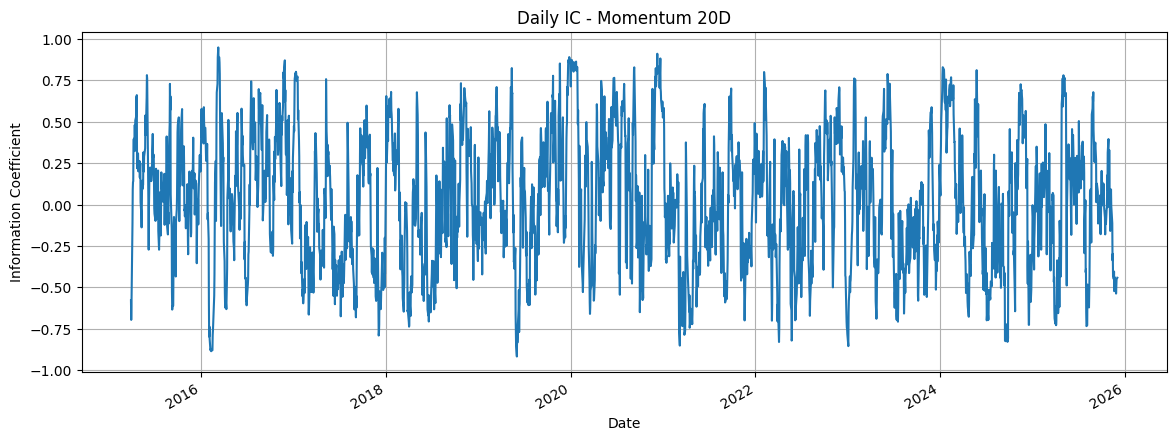

In [53]:
ic_momentum_20d.plot(figsize=(14, 5))

plt.title("Daily IC - Momentum 20D")
plt.xlabel("Date")
plt.ylabel("Information Coefficient")
plt.grid(True)
plt.show()

In [54]:
def calculate_daily_ic(data, factor_col, target_col="future_return_20d"):
    daily_ic = data.groupby("date").apply(
        lambda x: x[factor_col].corr(x[target_col])
    )
    
    return daily_ic

In [55]:
ic_momentum_20d = calculate_daily_ic(factor_data, "momentum_20d")
ic_momentum_60d = calculate_daily_ic(factor_data, "momentum_60d")
ic_volatility_20d = calculate_daily_ic(factor_data, "volatility_20d")
ic_volatility_60d = calculate_daily_ic(factor_data, "volatility_60d")

/tmp/ipykernel_16/1410913224.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = data.groupby("date").apply(
/tmp/ipykernel_16/1410913224.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = data.groupby("date").apply(
/tmp/ipykernel_16/1410913224.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the groupi

In [56]:
ic_summary = pd.DataFrame({
    "factor": [
        "momentum_20d",
        "momentum_60d",
        "volatility_20d",
        "volatility_60d"
    ],
    "mean_ic": [
        ic_momentum_20d.mean(),
        ic_momentum_60d.mean(),
        ic_volatility_20d.mean(),
        ic_volatility_60d.mean()
    ],
    "std_ic": [
        ic_momentum_20d.std(),
        ic_momentum_60d.std(),
        ic_volatility_20d.std(),
        ic_volatility_60d.std()
    ]
})

ic_summary

,factor,mean_ic,std_ic
0,momentum_20d,0.023504,0.396345
1,momentum_60d,0.054196,0.416569
2,volatility_20d,0.115057,0.435789
3,volatility_60d,0.143899,0.458861


In [57]:
ic_summary.sort_values("mean_ic", ascending=False)

,factor,mean_ic,std_ic
3,volatility_60d,0.143899,0.458861
2,volatility_20d,0.115057,0.435789
1,momentum_60d,0.054196,0.416569
0,momentum_20d,0.023504,0.396345


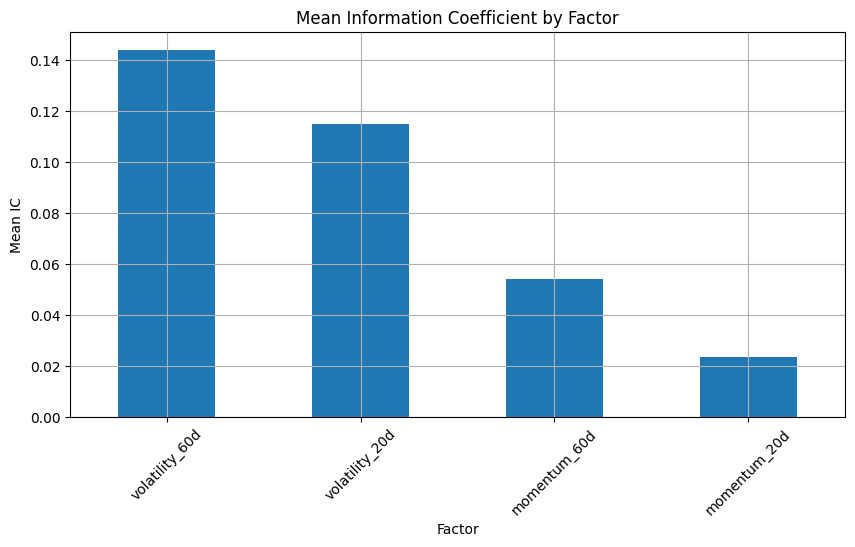

In [58]:
ic_summary_sorted = ic_summary.sort_values("mean_ic", ascending=False)

ic_summary_sorted.plot(
    x="factor",
    y="mean_ic",
    kind="bar",
    figsize=(10, 5),
    legend=False
)

plt.title("Mean Information Coefficient by Factor")
plt.xlabel("Factor")
plt.ylabel("Mean IC")
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

In [59]:
ic_timeseries = pd.DataFrame({
    "momentum_20d": ic_momentum_20d,
    "momentum_60d": ic_momentum_60d,
    "volatility_20d": ic_volatility_20d,
    "volatility_60d": ic_volatility_60d
})

ic_timeseries.head()

,momentum_20d,momentum_60d,volatility_20d,volatility_60d
date,,,,
2015-03-31,-0.578755,-0.256196,0.450220,0.774051
2015-04-01,-0.695744,-0.241056,0.396593,0.732203
2015-04-02,-0.611664,-0.160791,0.412706,0.750267
2015-04-06,-0.109910,-0.026650,0.421639,0.727362
2015-04-07,0.092116,0.000281,0.390163,0.730121


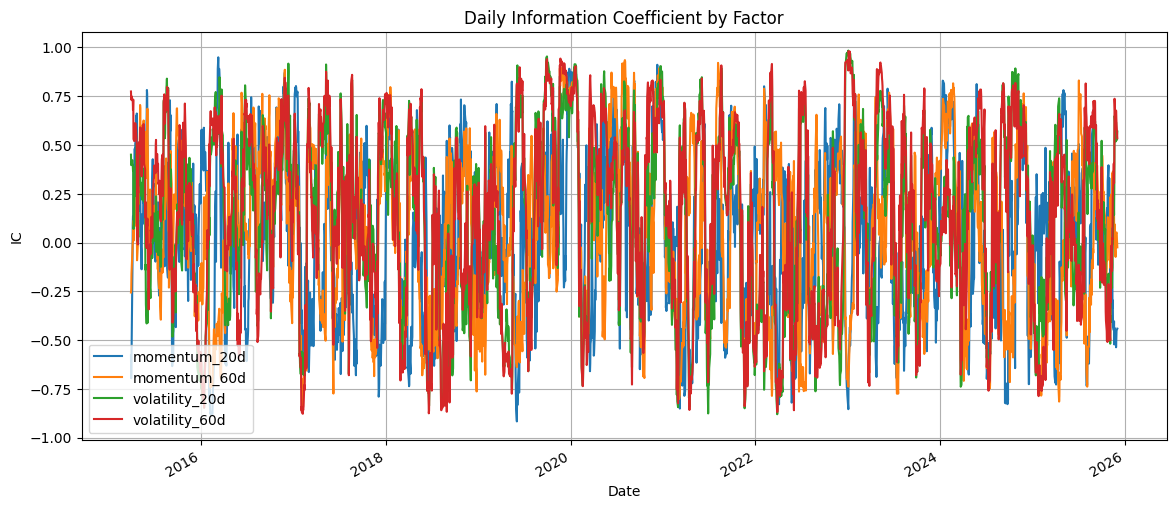

In [60]:
ic_timeseries.plot(figsize=(14, 6))

plt.title("Daily Information Coefficient by Factor")
plt.xlabel("Date")
plt.ylabel("IC")
plt.grid(True)
plt.show()

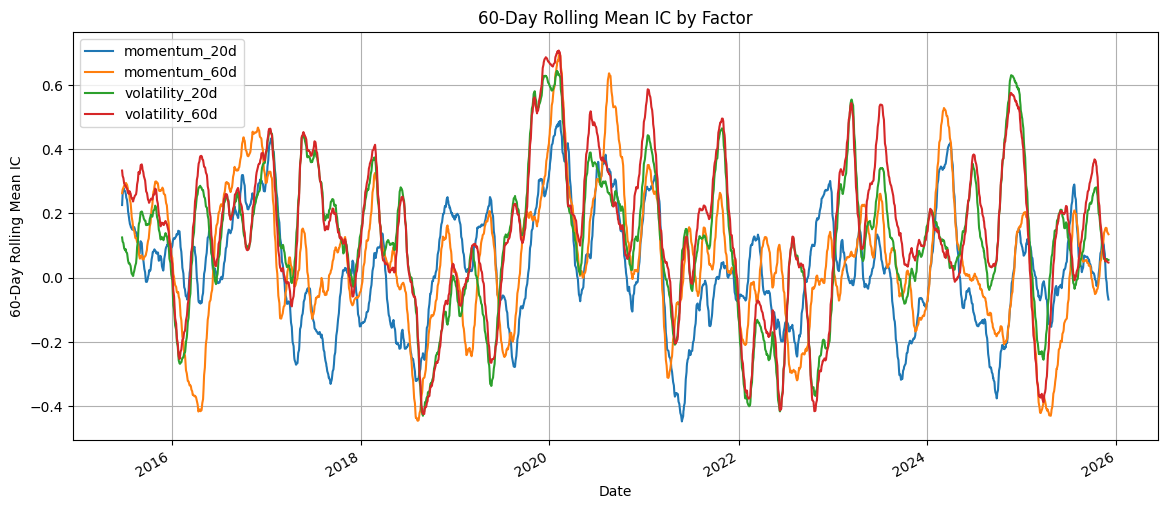

In [61]:
ic_timeseries.rolling(60).mean().plot(figsize=(14, 6))

plt.title("60-Day Rolling Mean IC by Factor")
plt.xlabel("Date")
plt.ylabel("60-Day Rolling Mean IC")
plt.grid(True)
plt.show()

In [62]:
ic_timeseries.head()

,momentum_20d,momentum_60d,volatility_20d,volatility_60d
date,,,,
2015-03-31,-0.578755,-0.256196,0.450220,0.774051
2015-04-01,-0.695744,-0.241056,0.396593,0.732203
2015-04-02,-0.611664,-0.160791,0.412706,0.750267
2015-04-06,-0.109910,-0.026650,0.421639,0.727362
2015-04-07,0.092116,0.000281,0.390163,0.730121


In [63]:
temp = factor_data.copy()

temp["volatility_60d_quantile"] = temp.groupby("date")["volatility_60d"].transform(
    lambda x: pd.qcut(x, q=5, labels=False, duplicates="drop") + 1
)

temp.head()

,date,ticker,price,daily_return,momentum_20d,momentum_60d,volatility_20d,volatility_60d,future_return_20d,momentum_20d_quantile,volatility_60d_quantile
0,2015-03-31,AAPL,27.668076,-0.015352,-0.038111,0.142606,0.014401,0.017536,0.033834,2,4
1,2015-03-31,AMZN,18.605000,-0.006647,-0.032526,0.206081,0.011759,0.022583,0.153910,3,5
2,2015-03-31,GOOGL,27.507648,-0.011477,-0.041621,0.047493,0.012188,0.014493,0.012061,2,3
3,2015-03-31,JNJ,74.193459,-0.009354,-0.017002,-0.030767,0.011795,0.011548,-0.002088,4,2
4,2015-03-31,JPM,44.859947,-0.006234,-0.022430,-0.030565,0.012227,0.015263,0.056829,4,3


In [64]:
vol_60d_quantile_returns = temp.groupby(
    ["date", "volatility_60d_quantile"]
)["future_return_20d"].mean().unstack()

vol_60d_quantile_returns.head()

volatility_60d_quantile,1,2,3,4,5
date,,,,,
2015-03-31,-0.010706,-0.007151,0.015868,0.066954,0.147705
2015-04-01,-0.009667,0.000667,0.006131,0.050077,0.133602
2015-04-02,-0.004610,0.010836,0.012581,0.067088,0.133211
2015-04-06,-0.011736,0.012135,0.014198,0.048311,0.100113
2015-04-07,-0.011631,-0.000694,-0.000941,0.036859,0.092948


In [65]:
vol_60d_spread_ts = vol_60d_quantile_returns[5] - vol_60d_quantile_returns[1]

vol_60d_spread_ts.head()

date
2015-03-31    0.158411
2015-04-01    0.143269
2015-04-02    0.137822
2015-04-06    0.111849
2015-04-07    0.104579
dtype: float64

In [66]:
vol_60d_spread_ts.describe()

count    2685.000000
mean        0.028961
std         0.103001
min        -0.323469
25%        -0.032948
50%         0.029075
75%         0.085245
max         0.611093
dtype: float64

In [67]:
positive_spread_ratio = (vol_60d_spread_ts > 0).mean()

print("Positive Spread Ratio:", positive_spread_ratio)

Positive Spread Ratio: 0.6346368715083799


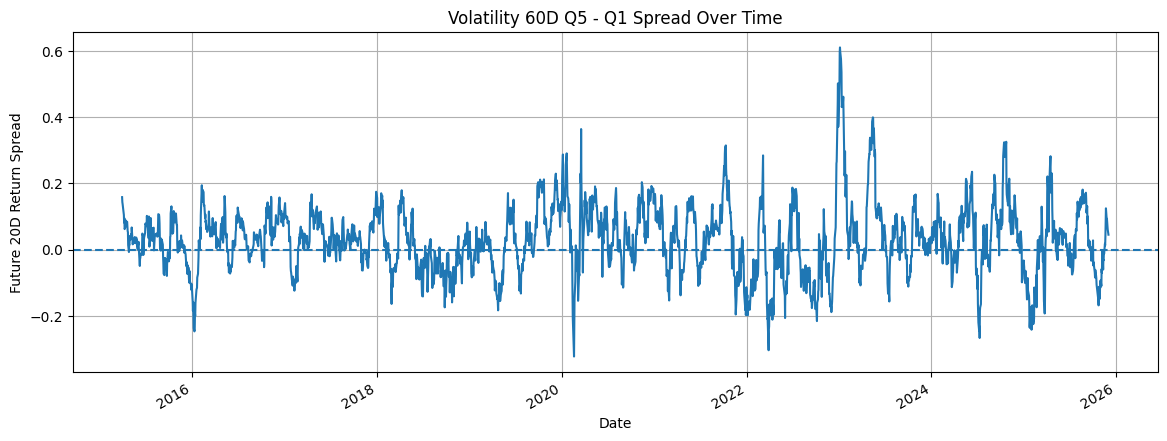

In [68]:
vol_60d_spread_ts.plot(figsize=(14, 5))

plt.axhline(0, linestyle="--")

plt.title("Volatility 60D Q5 - Q1 Spread Over Time")
plt.xlabel("Date")
plt.ylabel("Future 20D Return Spread")
plt.grid(True)
plt.show()

In [69]:
positive_spread_ratio

np.float64(0.6346368715083799)

In [70]:
ticker_summary = factor_data.groupby("ticker").agg(
    avg_future_return_20d=("future_return_20d", "mean"),
    avg_momentum_20d=("momentum_20d", "mean"),
    avg_momentum_60d=("momentum_60d", "mean"),
    avg_volatility_20d=("volatility_20d", "mean"),
    avg_volatility_60d=("volatility_60d", "mean")
).reset_index()

ticker_summary

,ticker,avg_future_return_20d,avg_momentum_20d,avg_momentum_60d,avg_volatility_20d,avg_volatility_60d
0,AAPL,0.020107,0.020074,0.061137,0.016492,0.017083
1,AMZN,0.022143,0.022659,0.069942,0.018985,0.019634
2,GOOGL,0.020946,0.020236,0.059790,0.016815,0.017276
3,JNJ,0.008733,0.008277,0.023092,0.010244,0.010683
4,JPM,0.016812,0.016752,0.051172,0.014836,0.015411
5,KO,0.007664,0.007711,0.021189,0.009858,0.010191
6,META,0.020444,0.020095,0.066677,0.021103,0.021970
7,MSFT,0.021264,0.021564,0.064811,0.015299,0.015816
8,NVDA,0.053216,0.053281,0.170237,0.028433,0.029448
9,PEP,0.006623,0.006504,0.018398,0.010420,0.010774


In [71]:
ticker_summary.sort_values("avg_future_return_20d", ascending=False)

,ticker,avg_future_return_20d,avg_momentum_20d,avg_momentum_60d,avg_volatility_20d,avg_volatility_60d
8,NVDA,0.053216,0.053281,0.170237,0.028433,0.029448
11,TSLA,0.042299,0.042124,0.127049,0.033770,0.034683
1,AMZN,0.022143,0.022659,0.069942,0.018985,0.019634
7,MSFT,0.021264,0.021564,0.064811,0.015299,0.015816
2,GOOGL,0.020946,0.020236,0.059790,0.016815,0.017276
6,META,0.020444,0.020095,0.066677,0.021103,0.021970
0,AAPL,0.020107,0.020074,0.061137,0.016492,0.017083
4,JPM,0.016812,0.016752,0.051172,0.014836,0.015411
13,WMT,0.013950,0.013015,0.038034,0.012051,0.012697
12,UNH,0.011842,0.011778,0.036488,0.015641,0.016216


In [72]:
ticker_summary.sort_values("avg_volatility_60d", ascending=False)

,ticker,avg_future_return_20d,avg_momentum_20d,avg_momentum_60d,avg_volatility_20d,avg_volatility_60d
11,TSLA,0.042299,0.042124,0.127049,0.033770,0.034683
8,NVDA,0.053216,0.053281,0.170237,0.028433,0.029448
6,META,0.020444,0.020095,0.066677,0.021103,0.021970
1,AMZN,0.022143,0.022659,0.069942,0.018985,0.019634
2,GOOGL,0.020946,0.020236,0.059790,0.016815,0.017276
0,AAPL,0.020107,0.020074,0.061137,0.016492,0.017083
12,UNH,0.011842,0.011778,0.036488,0.015641,0.016216
7,MSFT,0.021264,0.021564,0.064811,0.015299,0.015816
14,XOM,0.008755,0.008745,0.024639,0.015332,0.015703
4,JPM,0.016812,0.016752,0.051172,0.014836,0.015411


In [73]:
factor_data_no_nvda_tsla = factor_data[
    ~factor_data["ticker"].isin(["NVDA", "TSLA"])
].copy()

factor_data_no_nvda_tsla.shape

(34905, 10)

In [74]:
mom20_no, mom20_no_spread = quantile_analysis(
    factor_data_no_nvda_tsla,
    factor_col="momentum_20d"
)

mom60_no, mom60_no_spread = quantile_analysis(
    factor_data_no_nvda_tsla,
    factor_col="momentum_60d"
)

vol20_no, vol20_no_spread = quantile_analysis(
    factor_data_no_nvda_tsla,
    factor_col="volatility_20d"
)

vol60_no, vol60_no_spread = quantile_analysis(
    factor_data_no_nvda_tsla,
    factor_col="volatility_60d"
)

Factor: momentum_20d
momentum_20d_quantile
1    0.014726
2    0.015493
3    0.011873
4    0.013188
5    0.016503
Name: future_return_20d, dtype: float64

Q5 - Q1 Spread: 0.0017773533163558657
Factor: momentum_60d
momentum_60d_quantile
1    0.016159
2    0.012725
3    0.011723
4    0.013162
5    0.017083
Name: future_return_20d, dtype: float64

Q5 - Q1 Spread: 0.0009235936899494174
Factor: volatility_20d
volatility_20d_quantile
1    0.008082
2    0.010082
3    0.016769
4    0.015480
5    0.020331
Name: future_return_20d, dtype: float64

Q5 - Q1 Spread: 0.0122494486670611
Factor: volatility_60d
volatility_60d_quantile
1    0.007543
2    0.009844
3    0.014972
4    0.020994
5    0.019149
Name: future_return_20d, dtype: float64

Q5 - Q1 Spread: 0.011605468887840177


In [75]:
factor_comparison_no_nvda_tsla = pd.DataFrame({
    "factor": [
        "momentum_20d",
        "momentum_60d",
        "volatility_20d",
        "volatility_60d"
    ],
    "q1_return": [
        mom20_no.loc[1],
        mom60_no.loc[1],
        vol20_no.loc[1],
        vol60_no.loc[1]
    ],
    "q5_return": [
        mom20_no.loc[5],
        mom60_no.loc[5],
        vol20_no.loc[5],
        vol60_no.loc[5]
    ],
    "q5_q1_spread": [
        mom20_no_spread,
        mom60_no_spread,
        vol20_no_spread,
        vol60_no_spread
    ]
})

factor_comparison_no_nvda_tsla_percent = factor_comparison_no_nvda_tsla.copy()

for col in ["q1_return", "q5_return", "q5_q1_spread"]:
    factor_comparison_no_nvda_tsla_percent[col] *= 100

factor_comparison_no_nvda_tsla_percent.sort_values(
    "q5_q1_spread",
    ascending=False
)

,factor,q1_return,q5_return,q5_q1_spread
2,volatility_20d,0.808153,2.033098,1.224945
3,volatility_60d,0.754328,1.914875,1.160547
0,momentum_20d,1.472572,1.650308,0.177735
1,momentum_60d,1.615930,1.708290,0.092359


NVDA and TSLA data were removed as a robustness check.

After removing these two stocks with high volatility and high yield profiles, the volatility factor remains positive, although the spread values ​​decrease.

This indicates that the volatility factor result is partly boosted by NVDA and TSLA, but the signal is not entirely dependent on these two stocks.

In [76]:
ic_mom20_no = calculate_daily_ic(factor_data_no_nvda_tsla, "momentum_20d")
ic_mom60_no = calculate_daily_ic(factor_data_no_nvda_tsla, "momentum_60d")
ic_vol20_no = calculate_daily_ic(factor_data_no_nvda_tsla, "volatility_20d")
ic_vol60_no = calculate_daily_ic(factor_data_no_nvda_tsla, "volatility_60d")

/tmp/ipykernel_16/1410913224.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = data.groupby("date").apply(
/tmp/ipykernel_16/1410913224.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = data.groupby("date").apply(
/tmp/ipykernel_16/1410913224.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the groupi

In [77]:
ic_summary_no_nvda_tsla = pd.DataFrame({
    "factor": [
        "momentum_20d",
        "momentum_60d",
        "volatility_20d",
        "volatility_60d"
    ],
    "mean_ic": [
        ic_mom20_no.mean(),
        ic_mom60_no.mean(),
        ic_vol20_no.mean(),
        ic_vol60_no.mean()
    ],
    "std_ic": [
        ic_mom20_no.std(),
        ic_mom60_no.std(),
        ic_vol20_no.std(),
        ic_vol60_no.std()
    ]
})

ic_summary_no_nvda_tsla.sort_values("mean_ic", ascending=False)

,factor,mean_ic,std_ic
3,volatility_60d,0.105137,0.410338
2,volatility_20d,0.086094,0.379364
1,momentum_60d,0.020583,0.376538
0,momentum_20d,0.010439,0.361165


After excluding NVDA and TSLA, the mean IC values declined across all factors. 
However, volatility-based factors remained stronger than momentum-based factors. 
The 60-day volatility factor achieved the highest mean IC after the exclusion, suggesting that the volatility signal was partially influenced by NVDA and TSLA but not entirely dependent on them.

# Conclusion

In this project, I tested whether simple momentum and volatility-based factors can explain future 20-day stock returns.

The analysis was conducted on 15 large-cap US stocks between 2015 and 2025. Four factors were tested:

- 20-day momentum
- 60-day momentum
- 20-day volatility
- 60-day volatility

The target variable was the future 20-day return.

## Main Findings

The quantile analysis showed that volatility-based factors had stronger Q5-Q1 spreads than momentum-based factors.

| Factor | Q1 Return | Q5 Return | Q5 - Q1 Spread |
|---|---:|---:|---:|
| volatility_60d | 0.75% | 3.65% | 2.90% |
| volatility_20d | 0.81% | 3.46% | 2.65% |
| momentum_60d | 2.15% | 3.01% | 0.86% |
| momentum_20d | 2.02% | 2.60% | 0.57% |

The Information Coefficient analysis also supported this result.

| Factor | Mean IC |
|---|---:|
| volatility_60d | 0.1439 |
| volatility_20d | 0.1151 |
| momentum_60d | 0.0542 |
| momentum_20d | 0.0235 |

These results suggest that, in this selected universe, volatility-based factors had a stronger relationship with future 20-day returns than momentum-based factors.

## Robustness Check

A robustness check was performed by excluding NVDA and TSLA, two stocks with very high realized returns and volatility during the sample period.

After removing NVDA and TSLA, the volatility factor spreads decreased but remained positive.

| Factor | Q1 Return | Q5 Return | Q5 - Q1 Spread |
|---|---:|---:|---:|
| volatility_20d | 0.81% | 2.03% | 1.22% |
| volatility_60d | 0.75% | 1.91% | 1.16% |
| momentum_20d | 1.47% | 1.65% | 0.18% |
| momentum_60d | 1.62% | 1.71% | 0.09% |

The IC values also declined after excluding NVDA and TSLA, but volatility-based factors still remained stronger than momentum-based factors.

| Factor | Mean IC After Exclusion |
|---|---:|
| volatility_60d | 0.1051 |
| volatility_20d | 0.0861 |
| momentum_60d | 0.0206 |
| momentum_20d | 0.0104 |

This suggests that the volatility signal was partially influenced by NVDA and TSLA, but it was not entirely dependent on them.

## Interpretation

The strongest factor in this analysis was 60-day volatility. Stocks with higher recent volatility tended to have higher future 20-day returns in this sample.

However, this should not be interpreted as a complete trading strategy. The analysis does not yet include:

- transaction costs
- slippage
- portfolio constraints
- position sizing
- sector neutrality
- risk-adjusted performance
- out-of-sample testing

Therefore, the result should be interpreted as an initial factor research finding, not as a direct investment rule.

## Limitations

This project has several limitations:

1. The stock universe is small and consists of only 15 large-cap US stocks.
2. The results may be influenced by specific high-growth stocks such as NVDA and TSLA.
3. The analysis does not control for sector exposure.
4. The future return horizon is fixed at 20 trading days.
5. The study does not include a full portfolio backtest.

## Next Steps

Possible improvements for this project include:

- expanding the universe to S&P 500 stocks
- testing more factor definitions
- adding sector-neutral ranking
- testing multiple future return horizons
- adding transaction costs
- building a long-short factor portfolio
- performing walk-forward validation
- comparing raw returns with risk-adjusted returns

## Final Summary

Overall, this project shows how factor research can be used to evaluate whether financial signals contain predictive information. In this sample, volatility-based factors showed stronger predictive power than momentum-based factors, although the results should be validated on a larger stock universe and with more robust backtesting methods.